# Customer Segmentation Analysis — Data Science Month 1, Project 2 (FINAL)
### CloudExify Summer Internship 2026

**Goal:** Segment customers into meaningful groups using **RFM analysis** (Recency,
Frequency, Monetary) and **K-Means clustering**, then translate the clusters into
actionable business recommendations.

**Contents**
1. Introduction
2. RFM calculation
3. Normalization
4. Elbow method to choose K
5. K-Means clustering
6. Segment profiling
7. Visualization
8. Business insights & final report


## 1. Introduction

Customer segmentation groups customers with similar purchasing behavior so a business
can target marketing, improve service, and increase revenue. We use **K-Means**, an
unsupervised algorithm that finds K center points ("centroids") and assigns each
customer to the nearest one, producing K distinct segments.

## Step 1 — Calculate RFM Scores

In [4]:
import pandas as pd
from datetime import datetime

# Load customer transaction data
df = pd.read_csv('sample_data/customer_transactions.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Transactions:", df.shape)
df.head()


Transactions: (2624, 5)


In [5]:
# Reference date ("today") — one day after the latest transaction in the dataset
reference_date = datetime(2026, 6, 5)

# Calculate RFM
rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'TransactionID': 'count',
    'Amount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.shape)
rfm.head()


(300, 3)


In [6]:
rfm.describe()


## Step 2 — Normalize the Data

K-Means uses distance, so features must be on the same scale. We use `StandardScaler`.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)
rfm_scaled_df.head()


## Step 3 — Elbow Method to Choose K

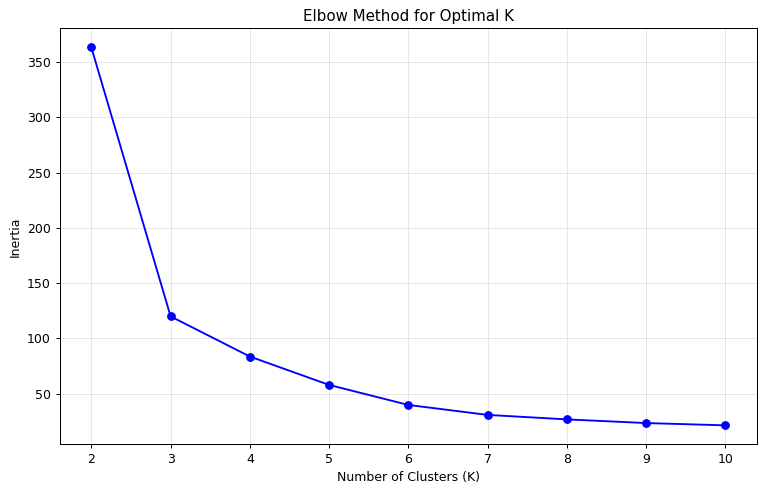

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(K_range), inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(alpha=0.3)
plt.show()

# The "elbow" — where inertia stops dropping sharply — appears around K = 3,
# which also matches the three natural value tiers (High / Mid / Low) we expect
# in a typical customer base.


## Step 4 — Apply K-Means Clustering (K = 3)

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

rfm.head(10)


In [13]:
# Map numeric clusters to human-readable names based on average Monetary value
# (highest average spend = High-Value, lowest = Low-Value)
cluster_order = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).index
segment_names = {
    cluster_order[0]: 'High-Value',
    cluster_order[1]: 'Mid-Value',
    cluster_order[2]: 'Low-Value'
}
rfm['SegmentName'] = rfm['Segment'].map(segment_names)

rfm.head(10)


## Step 5 — Profile Each Segment

In [15]:
segment_profiles = rfm.groupby('SegmentName').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# Order rows logically: High -> Mid -> Low
segment_profiles = segment_profiles.reindex(['High-Value', 'Mid-Value', 'Low-Value'])
print(segment_profiles)

print("\nSegment Sizes:")
print(rfm['SegmentName'].value_counts().reindex(['High-Value', 'Mid-Value', 'Low-Value']))


             Recency  Frequency  Monetary
SegmentName                              
High-Value       7.7       22.2  109656.3
Mid-Value       37.4        9.4   13871.9
Low-Value      134.1        2.5    1597.0

Segment Sizes:
SegmentName
High-Value     47
Mid-Value     138
Low-Value     115
Name: count, dtype: int64


In [16]:
# Segment size as a percentage of the total customer base
segment_pct = (rfm['SegmentName'].value_counts(normalize=True) * 100).round(1)
segment_pct.reindex(['High-Value', 'Mid-Value', 'Low-Value'])


## Step 6 — Visualization

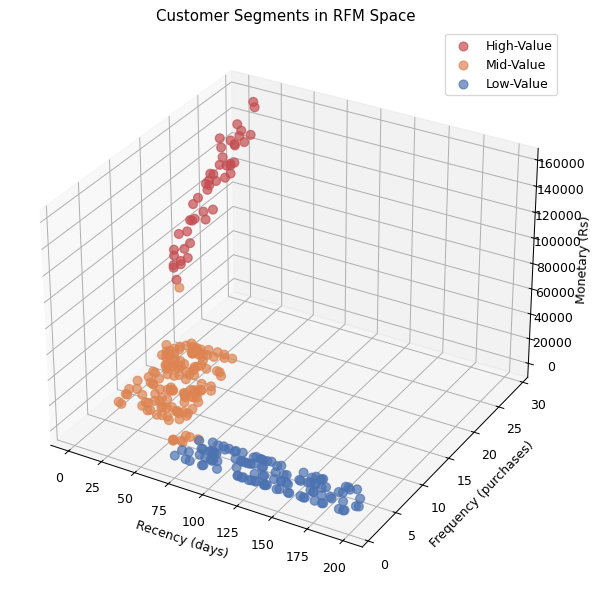

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'High-Value': '#C44E52', 'Mid-Value': '#DD8452', 'Low-Value': '#4C72B0'}

for segment in ['High-Value', 'Mid-Value', 'Low-Value']:
    mask = rfm['SegmentName'] == segment
    ax.scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Frequency'],
        rfm[mask]['Monetary'],
        label=segment, s=50, color=colors[segment], alpha=0.7
    )

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (purchases)')
ax.set_zlabel('Monetary (Rs)')
ax.set_title('Customer Segments in RFM Space')
ax.legend()
plt.show()


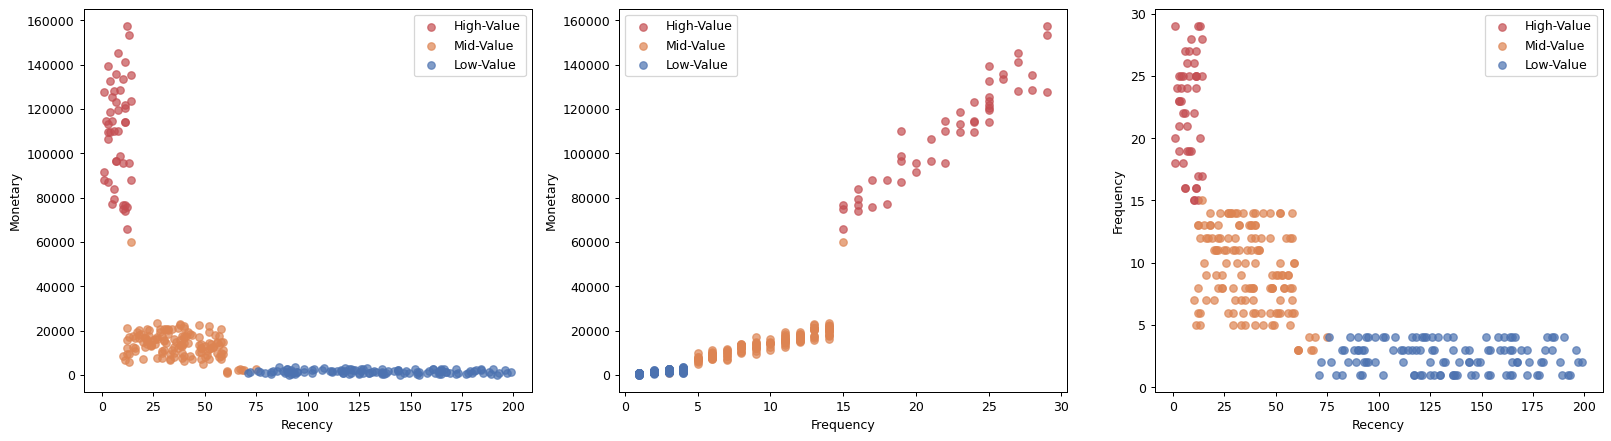

In [19]:
# 2D views for easier reading alongside the 3D plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('Recency', 'Monetary'), ('Frequency', 'Monetary'), ('Recency', 'Frequency')]

for ax, (x, y) in zip(axes, pairs):
    for segment in ['High-Value', 'Mid-Value', 'Low-Value']:
        mask = rfm['SegmentName'] == segment
        ax.scatter(rfm[mask][x], rfm[mask][y], label=segment, color=colors[segment], alpha=0.7)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()

plt.tight_layout()
plt.show()


## 4. Business Insights & Recommendations

In [21]:
recommendations = {
    'High-Value': 'VIP treatment - exclusive offers, priority service',
    'Mid-Value': 'Growth potential - targeted campaigns, loyalty programs',
    'Low-Value': 'Win-back campaigns - special discounts, re-engagement offers'
}

for segment, rec in recommendations.items():
    print(f"{segment}: {rec}")


High-Value: VIP treatment - exclusive offers, priority service
Mid-Value: Growth potential - targeted campaigns, loyalty programs
Low-Value: Win-back campaigns - special discounts, re-engagement offers


## 5. Final Report

In [23]:
print("="*60)
print("CUSTOMER SEGMENTATION ANALYSIS REPORT")
print("="*60)
print(f"Total Customers: {len(rfm)}")
print(f"\nSegment Distribution:")
print(rfm['SegmentName'].value_counts().reindex(['High-Value', 'Mid-Value', 'Low-Value']))
print(f"\nSegment Profiles (average R/F/M):")
print(segment_profiles)
print(f"\nRecommendations:")
for segment, rec in recommendations.items():
    print(f"{segment}: {rec}")


CUSTOMER SEGMENTATION ANALYSIS REPORT
Total Customers: 300

Segment Distribution:
SegmentName
High-Value     47
Mid-Value     138
Low-Value     115
Name: count, dtype: int64

Segment Profiles (average R/F/M):
             Recency  Frequency  Monetary
SegmentName                              
High-Value       7.7       22.2  109656.3
Mid-Value       37.4        9.4   13871.9
Low-Value      134.1        2.5    1597.0

Recommendations:
High-Value: VIP treatment - exclusive offers, priority service
Mid-Value: Growth potential - targeted campaigns, loyalty programs
Low-Value: Win-back campaigns - special discounts, re-engagement offers


In [24]:
# Export final segmented customer table
rfm.reset_index().to_csv('sample_data/customer_segments_output.csv', index=False)
print("Saved: sample_data/customer_segments_output.csv")


Saved: sample_data/customer_segments_output.csv


## 6. Conclusion

Using RFM analysis and K-Means clustering, customers were grouped into three
data-driven segments:

- **High-Value** — recent, frequent, big spenders. Priority: retention and VIP
  experience, since losing these customers has the largest revenue impact.
- **Mid-Value** — moderately active customers with room to grow. Priority: loyalty
  programs and upsell campaigns to push them toward High-Value.
- **Low-Value** — infrequent or lapsed customers. Priority: win-back campaigns and
  discounts to re-engage them before they churn completely.

This segmentation gives the business a concrete, quantified basis for prioritizing
marketing spend rather than treating all customers the same way.
